# Subset ML Prediction Notebook

## Goal
Train machine learning models to predict next-run CPU and memory demand using historical recurring-job features derived from the subset trace, then convert those predictions into practical recommendation policies for resource provisioning.

## Inputs
- `job_metrics_train_v0.parquet`
- `job_metrics_val_with_baselines_v0.parquet`
- `job_metrics_test_with_baselines_v0.parquet`
- `job_profiles_train_only_v0.parquet`

## Targets
### Prediction Targets
- `peak_cpu`
- `peak_mem_gb`

### Recommendation Outputs
- recommended CPU
- recommended memory

## Models Evaluated
### Regression Models
- Decision Tree Regressor
- Random Forest Regressor
- XGBoost Regressor

### Classification Models
(Resource Central–style 4-bucket demand classes)

- Decision Tree Classifier
- Random Forest Classifier
- XGBoost Classifier

## Recommendation Policies Compared
- **As-Is:** original requested resources from the trace
- **Baseline:** best historical baseline estimator
- **ML:** best learned regression model
- **Hybrid:** ML forecast combined with conservative baseline safeguard

## Evaluation Metrics
### Prediction Metrics
- MAE
- RMSE
- R²

### Classification Metrics
- Accuracy
- Precision
- Recall
- F1-score

### Recommendation Quality Metrics
- Violation rate
- Coverage / safety
- Average slack
- Average overprovisioning
- Average underprovisioning
- Waste reduction vs. As-Is

## Notes
- GPU is not modeled in this notebook because the subset trace does not contain usable GPU resource fields for this stage.
- CPU recommendations benefited most from hybrid ML + baseline safeguards.
- Memory recommendations were more conservative, with historical requests remaining strong baselines.
- Fair policy comparisons are included using common-row evaluation where all recommendation columns are available.

In [191]:
import sys
from pathlib import Path
import pandas as pd
import numpy as np

# Regression models
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

# Classification models
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

# Metrics
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)

IN_COLAB = "google.colab" in sys.modules

if IN_COLAB:
    from google.colab import drive
    drive.mount("/content/drive", force_remount=False)
    REPO_ROOT = Path("/content/drive/Shareddrives/CMPE 295A_B/subset")
else:
    REPO_ROOT = Path.cwd()
    while REPO_ROOT.name != "masters-project" and REPO_ROOT.parent != REPO_ROOT:
        REPO_ROOT = REPO_ROOT.parent
    if REPO_ROOT.name != "masters-project":
        raise RuntimeError("Could not find repo root folder named 'masters-project'.")
    
# Project Folders
DATA_PROCESSED = REPO_ROOT / "data" / "processed"
NOTEBOOK_DIR = REPO_ROOT / "notebooks" / "subset"
REPORTS_DIR = REPO_ROOT / "reports" / "eval" / "subset"
TABLE_DIR = REPORTS_DIR / "tables"
FIG_DIR = REPORTS_DIR / "figures"
FIG_ML_DIR = REPORTS_DIR / "figures_ml"

TRAIN_PATH = DATA_PROCESSED / "job_metrics_train_v0.parquet"
VAL_PATH   = DATA_PROCESSED / "job_metrics_val_with_baselines_v0.parquet"
TEST_PATH  = DATA_PROCESSED / "job_metrics_test_with_baselines_v0.parquet"

VAL_OUT_PATH = DATA_PROCESSED / "job_metrics_val_with_ml_v0.parquet"
TEST_OUT_PATH = DATA_PROCESSED / "job_metrics_test_with_ml_v0.parquet"

REPORTS_DIR.mkdir(parents=True, exist_ok=True)
TABLE_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)
FIG_ML_DIR.mkdir(parents=True, exist_ok=True)

# Input files
TRAIN_PATH = DATA_PROCESSED / "job_metrics_train_v0.parquet"
VAL_PATH   = DATA_PROCESSED / "job_metrics_val_with_baselines_v0.parquet"
TEST_PATH  = DATA_PROCESSED / "job_metrics_test_with_baselines_v0.parquet"
PROFILES_PATH = DATA_PROCESSED / "job_profiles_train_only_v0.parquet"

# Output files
VAL_OUT_PATH = DATA_PROCESSED / "job_metrics_val_with_ml_v0.parquet"
TEST_OUT_PATH = DATA_PROCESSED / "job_metrics_test_with_ml_v0.parquet"

REG_RESULTS_PATH = TABLE_DIR / "ml_regression_summary_v0.csv"
CLS_RESULTS_PATH = TABLE_DIR / "ml_classification_summary_v0.csv"

# Quick path check
print("Repo root:", REPO_ROOT)
print("Train file exists:", TRAIN_PATH.exists())
print("Val file exists  :", VAL_PATH.exists())
print("Test file exists :", TEST_PATH.exists())
print("Profiles exists  :", PROFILES_PATH.exists())

Repo root: /Users/sofiasilva/Masters-project/masters-project
Train file exists: True
Val file exists  : True
Test file exists : True
Profiles exists  : True


Load Dataset

In [192]:
# Load train / validation / test datasets
train_df = pd.read_parquet(TRAIN_PATH)
val_df = pd.read_parquet(VAL_PATH)
test_df = pd.read_parquet(TEST_PATH)

print("Train shape:", train_df.shape)
print("Val shape  :", val_df.shape)
print("Test shape :", test_df.shape)

# Preview training data
display(train_df.head())

# Show available columns
print("Train columns:")
for c in train_df.columns:
    print(c)

Train shape: (50220, 13)
Val shape  : (10762, 48)
Test shape : (10762, 48)


,execution_id,job_id,start_time,end_time,req_cpu,req_mem_gb,peak_cpu,peak_mem_gb,recurrence_key,timestamp,duration,slack_req_cpu,slack_req_mem_gb
0,261561475113_257,261561475113,1970-01-01 00:00:00.600,1970-01-01 00:00:00.900,0.022461,0.011826,0.001186,0.004662,DrrEIEWkWuW7RrZwpHLCN0k0A2J0usJeyt3wtqzZ7Kk=||...,600000000,300000000,0.021275,0.007164
1,261561475113_575,261561475113,1970-01-01 00:00:00.600,1970-01-01 00:00:00.900,0.022461,0.011826,0.001186,0.004662,DrrEIEWkWuW7RrZwpHLCN0k0A2J0usJeyt3wtqzZ7Kk=||...,600000000,300000000,0.021275,0.007164
2,315268937205_12156,315268937205,1970-01-01 00:00:01.200,1970-01-01 00:00:01.500,0.005669,0.001562,0.009369,0.001049,jW2GJpOlCheoSzGcwfmRjkjV6mYZo4DC43ej/X/OyjM=||...,1200000000,300000000,-0.003700,0.000513
3,315268937205_13226,315268937205,1970-01-01 00:00:01.200,1970-01-01 00:00:01.500,0.005669,0.001562,0.009369,0.001049,jW2GJpOlCheoSzGcwfmRjkjV6mYZo4DC43ej/X/OyjM=||...,1200000000,300000000,-0.003700,0.000513
4,315268937205_13445,315268937205,1970-01-01 00:00:01.200,1970-01-01 00:00:01.500,0.005669,0.001562,0.009369,0.001049,jW2GJpOlCheoSzGcwfmRjkjV6mYZo4DC43ej/X/OyjM=||...,1200000000,300000000,-0.003700,0.000513


Train columns:
execution_id
job_id
start_time
end_time
req_cpu
req_mem_gb
peak_cpu
peak_mem_gb
recurrence_key
timestamp
duration
slack_req_cpu
slack_req_mem_gb


In [193]:
# Define prediction targets
# CPU and memory are available in subset trace
# GPU is not available in this dataset

TARGET_CPU = "peak_cpu"
TARGET_MEM = "peak_mem_gb"
TARGET_GPU = None

print("CPU target:", TARGET_CPU)
print("MEM target:", TARGET_MEM)
print("GPU target: Not available in subset trace")

CPU target: peak_cpu
MEM target: peak_mem_gb
GPU target: Not available in subset trace


In [194]:
# Reload clean base tables
# Merge train-only historical profile features

train_df = pd.read_parquet(TRAIN_PATH)
val_df = pd.read_parquet(VAL_PATH)
test_df = pd.read_parquet(TEST_PATH)

profiles_df = pd.read_parquet(PROFILES_PATH)

print("Fresh train shape:", train_df.shape)
print("Fresh val shape  :", val_df.shape)
print("Fresh test shape :", test_df.shape)

train_df = train_df.merge(profiles_df, on="recurrence_key", how="left")
val_df = val_df.merge(profiles_df, on="recurrence_key", how="left")
test_df = test_df.merge(profiles_df, on="recurrence_key", how="left")

print("\nMerged train shape:", train_df.shape)
print("Merged val shape  :", val_df.shape)
print("Merged test shape :", test_df.shape)

Fresh train shape: (50220, 13)
Fresh val shape  : (10762, 48)
Fresh test shape : (10762, 48)

Merged train shape: (50220, 34)
Merged val shape  : (10762, 69)
Merged test shape : (10762, 69)


In [195]:
# Sanity check merged historical feature columns
# Confirm there are no duplicate _x / _y columns

profile_check_cols = [
    c for c in train_df.columns
    if "run_count" in c or "mean_peak" in c or "p95" in c or "confidence_tier" in c
]

print("Profile-related columns in train:")
print(profile_check_cols)

Profile-related columns in train:
['run_count', 'mean_peak_cpu', 'mean_peak_mem', 'confidence_tier', 'p95_cpu', 'p95_mem']


## Feature Selection
Final feature set used for CPU and memory prediction.

In [196]:
# Final feature set for ML models
# Includes direct request/runtime fields + historical profile features

feature_cols = [
    # direct request/runtime
    "req_cpu",
    "req_mem_gb",
    "duration",
    "slack_req_cpu",
    "slack_req_mem_gb",

    # recurrence/history
    "run_count",
    "is_recurring",
    "mean_duration",

    # cpu history
    "mean_peak_cpu",
    "std_peak_cpu",
    "cv_cpu",
    "p90_cpu",
    "p95_cpu",
    "p99_cpu",

    # memory history
    "mean_peak_mem",
    "std_peak_mem",
    "cv_mem",
    "p90_mem",
    "p95_mem",
    "p99_mem",

    # categorical profile/tier features
    "confidence_tier",
    "resource_profile",
    "duration_profile",
    "recurrence_profile",
    "stability_profile",
    "stability",
]

# Only keeping features that actually exist
feature_cols = [c for c in feature_cols if c in train_df.columns]
print("Final feature count:", len(feature_cols))
print(feature_cols)

Final feature count: 26
['req_cpu', 'req_mem_gb', 'duration', 'slack_req_cpu', 'slack_req_mem_gb', 'run_count', 'is_recurring', 'mean_duration', 'mean_peak_cpu', 'std_peak_cpu', 'cv_cpu', 'p90_cpu', 'p95_cpu', 'p99_cpu', 'mean_peak_mem', 'std_peak_mem', 'cv_mem', 'p90_mem', 'p95_mem', 'p99_mem', 'confidence_tier', 'resource_profile', 'duration_profile', 'recurrence_profile', 'stability_profile', 'stability']


## Matrix Construction
Converts the selected feature set into aligned train, validation, and test matrices for CPU and memory prediction.
- Categorical features are one-hot encoded and missing values are filled before modeling.

In [197]:
# Helper functions for ML-ready matrices
# - Select feature columns
# - One-hot encode categorical variables
# - Fill missing values
# - Align train / validation / test columns

def prepare_xy(df, feature_cols, target_col):
    X = df[feature_cols].copy()
    y = df[target_col].copy()

    # One-hot encode categorical features
    X = pd.get_dummies(X, dummy_na=True)

    # Fill missing values after encoding
    X = X.fillna(0)

    return X, y


def build_aligned_matrices(train_df, val_df, test_df, feature_cols, target_col):
    # Build feature/target matrices for each split
    X_train, y_train = prepare_xy(train_df, feature_cols, target_col)
    X_val, y_val = prepare_xy(val_df, feature_cols, target_col)
    X_test, y_test = prepare_xy(test_df, feature_cols, target_col)

    # Align columns across all splits
    all_cols = sorted(set(X_train.columns) | set(X_val.columns) | set(X_test.columns))

    X_train = X_train.reindex(columns=all_cols, fill_value=0)
    X_val = X_val.reindex(columns=all_cols, fill_value=0)
    X_test = X_test.reindex(columns=all_cols, fill_value=0)

    return X_train, y_train, X_val, y_val, X_test, y_test

In [198]:
# Building aligned matrices for CPU and memory targets

# CPU prediction matrices
X_train_cpu, y_train_cpu, X_val_cpu, y_val_cpu, X_test_cpu, y_test_cpu = build_aligned_matrices(
    train_df, val_df, test_df, feature_cols, TARGET_CPU
)
# Memory prediction matrices
X_train_mem, y_train_mem, X_val_mem, y_val_mem, X_test_mem, y_test_mem = build_aligned_matrices(
    train_df, val_df, test_df, feature_cols, TARGET_MEM
)

# Display matrix sizes
print("CPU train matrix:", X_train_cpu.shape)
print("CPU val matrix  :", X_val_cpu.shape)
print("CPU test matrix :", X_test_cpu.shape)

print("MEM train matrix:", X_train_mem.shape)
print("MEM val matrix  :", X_val_mem.shape)
print("MEM test matrix :", X_test_mem.shape)

# Check aligned feature names
print("Example encoded feature columns:")
print(X_train_cpu.columns[:20].tolist())

CPU train matrix: (50220, 43)
CPU val matrix  : (10762, 43)
CPU test matrix : (10762, 43)
MEM train matrix: (50220, 43)
MEM val matrix  : (10762, 43)
MEM test matrix : (10762, 43)
Example encoded feature columns:
['confidence_tier_high', 'confidence_tier_low', 'confidence_tier_medium', 'confidence_tier_nan', 'cv_cpu', 'cv_mem', 'duration', 'duration_profile_long', 'duration_profile_nan', 'is_recurring', 'is_recurring_False', 'is_recurring_True', 'is_recurring_nan', 'mean_duration', 'mean_peak_cpu', 'mean_peak_mem', 'p90_cpu', 'p90_mem', 'p95_cpu', 'p95_mem']


## Regression Modeling
Train and compare three regression models for exact next-run CPU and memory forecasting:
- Decision Tree Regressor
- Random Forest Regressor
- XGBoost Regressor

Evaluation metrics:
- MAE
- RMSE
- R²

In [199]:
# Regression models for next-run resource forecasting
reg_models = {
    "decision_tree": DecisionTreeRegressor(
        max_depth=8,
        min_samples_leaf=10,
        random_state=42
    ),
    "random_forest": RandomForestRegressor(
        n_estimators=200,
        max_depth=12,
        min_samples_leaf=5,
        random_state=42,
        n_jobs=-1
    ),
    "xgboost": XGBRegressor(
        n_estimators=300,
        max_depth=6,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        objective="reg:squarederror",
        random_state=42,
        n_jobs=-1
    )
}

In [200]:
# Regression evaluation metrics

def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))


def evaluate_regression(model_name, split_name, resource_name, y_true, y_pred):
    return {
        "model": model_name,
        "split": split_name,
        "resource": resource_name,
        "mae": mean_absolute_error(y_true, y_pred),
        "rmse": rmse(y_true, y_pred),
        "r2": r2_score(y_true, y_pred)
    }

In [201]:
# Training regression models for CPU prediction
regression_results = []

for model_name, model in reg_models.items():
    # Fit model on CPU target
    model.fit(X_train_cpu, y_train_cpu)

    # Predict validation and test splits
    val_pred = model.predict(X_val_cpu)
    test_pred = model.predict(X_test_cpu)

    # Save predictions
    val_df[f"pred_cpu_{model_name}"] = val_pred
    test_df[f"pred_cpu_{model_name}"] = test_pred

    # Save evaluation results
    regression_results.append(
        evaluate_regression(model_name, "val", "cpu", y_val_cpu, val_pred)
    )
    regression_results.append(
        evaluate_regression(model_name, "test", "cpu", y_test_cpu, test_pred)
    )

cpu_reg_results_df = pd.DataFrame(regression_results)
display(
    cpu_reg_results_df[cpu_reg_results_df["resource"] == "cpu"]
    .sort_values(["split", "rmse"])
)

,model,split,resource,mae,rmse,r2
3,random_forest,test,cpu,0.004152,0.015003,0.825476
5,xgboost,test,cpu,0.005348,0.015423,0.815553
1,decision_tree,test,cpu,0.004421,0.015714,0.808522
2,random_forest,val,cpu,0.003672,0.012353,0.938625
0,decision_tree,val,cpu,0.004511,0.013386,0.927932
4,xgboost,val,cpu,0.004836,0.013796,0.923445


In [202]:
# Training regression models for memory prediction
for model_name, model in reg_models.items():
    # Fit model on memory target
    model.fit(X_train_mem, y_train_mem)

    # Predict validation and test splits
    val_pred = model.predict(X_val_mem)
    test_pred = model.predict(X_test_mem)

    # Save predictions
    val_df[f"pred_mem_{model_name}"] = val_pred
    test_df[f"pred_mem_{model_name}"] = test_pred

    # Save evaluation results
    regression_results.append(
        evaluate_regression(model_name, "val", "mem", y_val_mem, val_pred)
    )
    regression_results.append(
        evaluate_regression(model_name, "test", "mem", y_test_mem, test_pred)
    )

regression_results_df = pd.DataFrame(regression_results)
display(
    regression_results_df.sort_values(["resource", "split", "rmse"])
)

,model,split,resource,mae,rmse,r2
3,random_forest,test,cpu,0.004152,0.015003,0.825476
5,xgboost,test,cpu,0.005348,0.015423,0.815553
1,decision_tree,test,cpu,0.004421,0.015714,0.808522
2,random_forest,val,cpu,0.003672,0.012353,0.938625
0,decision_tree,val,cpu,0.004511,0.013386,0.927932
4,xgboost,val,cpu,0.004836,0.013796,0.923445
11,xgboost,test,mem,0.001107,0.003020,0.814387
9,random_forest,test,mem,0.001321,0.003542,0.744748
7,decision_tree,test,mem,0.001424,0.003609,0.734871
10,xgboost,val,mem,0.001159,0.004541,0.767899


In [203]:
# Best regression model per resource and split
best_regression_models = (
    regression_results_df.sort_values("rmse")
    .groupby(["resource", "split"], as_index=False)
    .first()
)

display(best_regression_models)

,resource,split,model,mae,rmse,r2
0,cpu,test,random_forest,0.004152,0.015003,0.825476
1,cpu,val,random_forest,0.003672,0.012353,0.938625
2,mem,test,xgboost,0.001107,0.003020,0.814387
3,mem,val,xgboost,0.001159,0.004541,0.767899


Random Forest achieved the strongest CPU forecasting performance, while XGBoost achieved the best memory forecasting performance. Results indicate that historical recurring-job features provide substantial predictive value for next-run resource demand estimation.

## Resource Central–Style Classification

In addition to exact regression forecasting, this section bucketizes CPU and memory demand into four classes and evaluates prediction quality using:
- Accuracy
- Precision
- Recall
- F1-score

This mirrors the classification-style evaluation reported in Resource Central.

In [204]:
# Creating 4 demand buckets using train-set quantiles
def make_4_buckets_from_train(train_series, val_series, test_series):
    q1 = train_series.quantile(0.25)
    q2 = train_series.quantile(0.50)
    q3 = train_series.quantile(0.75)

    def bucketize(x):
        if x <= q1:
            return 0
        elif x <= q2:
            return 1
        elif x <= q3:
            return 2
        return 3

    return (
        train_series.apply(bucketize),
        val_series.apply(bucketize),
        test_series.apply(bucketize),
        (q1, q2, q3)
    )

# CPU bucket labels
y_train_cpu_cls, y_val_cpu_cls, y_test_cpu_cls, cpu_bucket_edges = make_4_buckets_from_train(
    y_train_cpu, y_val_cpu, y_test_cpu
)

# Memory bucket labels
y_train_mem_cls, y_val_mem_cls, y_test_mem_cls, mem_bucket_edges = make_4_buckets_from_train(
    y_train_mem, y_val_mem, y_test_mem
)

print("CPU bucket edges:", cpu_bucket_edges)
print("MEM bucket edges:", mem_bucket_edges)

print("\nCPU bucket counts (train):")
print(y_train_cpu_cls.value_counts().sort_index())

print("\nMEM bucket counts (train):")
print(y_train_mem_cls.value_counts().sort_index())

CPU bucket edges: (np.float64(0.0013523101806640625), np.float64(0.01092529296875), np.float64(0.045654296875))
MEM bucket edges: (np.float64(0.00066375732421875), np.float64(0.0016460418701171875), np.float64(0.00678253173828125))

CPU bucket counts (train):
peak_cpu
0    12576
1    12543
2    12563
3    12538
Name: count, dtype: int64

MEM bucket counts (train):
peak_mem_gb
0    12570
1    12752
2    12361
3    12537
Name: count, dtype: int64


In [205]:
# Classification models for bucket prediction
clf_models = {
    "decision_tree_cls": DecisionTreeClassifier(
        max_depth=8,
        min_samples_leaf=10,
        random_state=42
    ),
    "random_forest_cls": RandomForestClassifier(
        n_estimators=200,
        max_depth=12,
        min_samples_leaf=5,
        random_state=42,
        n_jobs=-1
    ),
    "xgboost_cls": XGBClassifier(
        n_estimators=300,
        max_depth=6,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        eval_metric="mlogloss",
        random_state=42,
        n_jobs=-1
    )
}

In [206]:
# Classification evaluation metrics
def evaluate_classification(model_name, split_name, resource_name, y_true, y_pred):
    return {
        "model": model_name,
        "split": split_name,
        "resource": resource_name,
        "accuracy": accuracy_score(y_true, y_pred),
        "precision_macro": precision_score(y_true, y_pred, average="macro", zero_division=0),
        "recall_macro": recall_score(y_true, y_pred, average="macro", zero_division=0),
        "f1_macro": f1_score(y_true, y_pred, average="macro", zero_division=0),
    }

In [207]:
# Training CPU bucket classification models
classification_results = []

for model_name, model in clf_models.items():
    model.fit(X_train_cpu, y_train_cpu_cls)

    val_pred = model.predict(X_val_cpu)
    test_pred = model.predict(X_test_cpu)

    val_df[f"pred_cpu_bucket_{model_name}"] = val_pred
    test_df[f"pred_cpu_bucket_{model_name}"] = test_pred

    classification_results.append(
        evaluate_classification(model_name, "val", "cpu_bucket", y_val_cpu_cls, val_pred)
    )
    classification_results.append(
        evaluate_classification(model_name, "test", "cpu_bucket", y_test_cpu_cls, test_pred)
    )

cpu_cls_results_df = pd.DataFrame(classification_results)
display(
    cpu_cls_results_df[cpu_cls_results_df["resource"] == "cpu_bucket"]
    .sort_values(["split", "accuracy"], ascending=[True, False])
)

,model,split,resource,accuracy,precision_macro,recall_macro,f1_macro
5,xgboost_cls,test,cpu_bucket,0.898253,0.909125,0.883646,0.892902
1,decision_tree_cls,test,cpu_bucket,0.838878,0.834981,0.786108,0.798492
3,random_forest_cls,test,cpu_bucket,0.648950,0.681681,0.591881,0.610724
4,xgboost_cls,val,cpu_bucket,0.809887,0.862107,0.800733,0.814309
0,decision_tree_cls,val,cpu_bucket,0.793719,0.800389,0.759142,0.766289
2,random_forest_cls,val,cpu_bucket,0.748839,0.821674,0.720476,0.739681


In [208]:
# Training memory bucket classification models
for model_name, model in clf_models.items():
    model.fit(X_train_mem, y_train_mem_cls)

    val_pred = model.predict(X_val_mem)
    test_pred = model.predict(X_test_mem)

    val_df[f"pred_mem_bucket_{model_name}"] = val_pred
    test_df[f"pred_mem_bucket_{model_name}"] = test_pred

    classification_results.append(
        evaluate_classification(model_name, "val", "mem_bucket", y_val_mem_cls, val_pred)
    )
    classification_results.append(
        evaluate_classification(model_name, "test", "mem_bucket", y_test_mem_cls, test_pred)
    )

classification_results_df = pd.DataFrame(classification_results)
display(
    classification_results_df.sort_values(["resource", "split", "accuracy"], ascending=[True, True, False])
)

,model,split,resource,accuracy,precision_macro,recall_macro,f1_macro
5,xgboost_cls,test,cpu_bucket,0.898253,0.909125,0.883646,0.892902
1,decision_tree_cls,test,cpu_bucket,0.838878,0.834981,0.786108,0.798492
3,random_forest_cls,test,cpu_bucket,0.648950,0.681681,0.591881,0.610724
4,xgboost_cls,val,cpu_bucket,0.809887,0.862107,0.800733,0.814309
0,decision_tree_cls,val,cpu_bucket,0.793719,0.800389,0.759142,0.766289
2,random_forest_cls,val,cpu_bucket,0.748839,0.821674,0.720476,0.739681
11,xgboost_cls,test,mem_bucket,0.738339,0.835517,0.776106,0.771486
9,random_forest_cls,test,mem_bucket,0.692622,0.779336,0.739292,0.724972
7,decision_tree_cls,test,mem_bucket,0.665676,0.760564,0.717709,0.698379
10,xgboost_cls,val,mem_bucket,0.744843,0.792868,0.760915,0.742555


In [209]:
# Best classification model per resource and split
best_classification_models = (
    classification_results_df.sort_values("accuracy", ascending=False)
    .groupby(["resource", "split"], as_index=False)
    .first()
)

display(best_classification_models)

,resource,split,model,accuracy,precision_macro,recall_macro,f1_macro
0,cpu_bucket,test,xgboost_cls,0.898253,0.909125,0.883646,0.892902
1,cpu_bucket,val,xgboost_cls,0.809887,0.862107,0.800733,0.814309
2,mem_bucket,test,xgboost_cls,0.738339,0.835517,0.776106,0.771486
3,mem_bucket,val,xgboost_cls,0.744843,0.792868,0.760915,0.742555


## Baseline Comparison

Compared learned ML models against historical baseline estimators that already are available in the validation split.

These baselines serve as:
- transparent reference methods
- fallback recommendation policies
- safety anchors for final hybrid recommendations

### Detailed Classification Reports
Validation-set classification report for the best CPU and memory bucket models.

In [210]:
best_cpu_cls_model_name = (
    classification_results_df[
        (classification_results_df["resource"] == "cpu_bucket") &
        (classification_results_df["split"] == "val")
    ]
    .sort_values("accuracy", ascending=False)
    .iloc[0]["model"]
)

best_cpu_cls_model = clf_models[best_cpu_cls_model_name]
best_cpu_cls_model.fit(X_train_cpu, y_train_cpu_cls)
best_cpu_val_pred = best_cpu_cls_model.predict(X_val_cpu)

print("Best CPU bucket model:", best_cpu_cls_model_name)
print(classification_report(y_val_cpu_cls, best_cpu_val_pred, zero_division=0))

Best CPU bucket model: xgboost_cls
              precision    recall  f1-score   support

           0       0.65      0.98      0.78      3087
           1       0.92      0.73      0.82      3540
           2       0.98      0.76      0.86      2480
           3       0.90      0.73      0.80      1655

    accuracy                           0.81     10762
   macro avg       0.86      0.80      0.81     10762
weighted avg       0.85      0.81      0.81     10762



In [211]:
# Detailed classification report for best memory model
best_mem_cls_model_name = (
    classification_results_df[
        (classification_results_df["resource"] == "mem_bucket") &
        (classification_results_df["split"] == "val")
    ]
    .sort_values("accuracy", ascending=False)
    .iloc[0]["model"]
)

best_mem_cls_model = clf_models[best_mem_cls_model_name]
best_mem_cls_model.fit(X_train_mem, y_train_mem_cls)
best_mem_val_pred = best_mem_cls_model.predict(X_val_mem)

print("Best memory bucket model:", best_mem_cls_model_name)
print(classification_report(y_val_mem_cls, best_mem_val_pred, zero_division=0))

Best memory bucket model: xgboost_cls
              precision    recall  f1-score   support

           0       0.45      0.94      0.61      1783
           1       0.90      0.79      0.85      4601
           2       0.88      0.56      0.68      3098
           3       0.94      0.76      0.84      1280

    accuracy                           0.74     10762
   macro avg       0.79      0.76      0.74     10762
weighted avg       0.83      0.74      0.76     10762



## Baseline Comparison

ML regression models compared against the historical baseline columns already present in the validation set.
- This helps determine whether learned models improve over percentile and history-based heuristics.

In [212]:
# Check baseline-related columns already present
baseline_cols = [
    c for c in val_df.columns
    if any(k in c.lower() for k in ["last", "mean", "p90", "p95", "p99", "baseline"])
]

print("Baseline-related columns found:")
for c in baseline_cols:
    print(c)

Baseline-related columns found:
hist_mean_peak_cpu
hist_mean_peak_mem
hist_mean_duration
hist_p90_cpu
hist_p95_cpu
hist_p99_cpu
hist_p90_mem
hist_p95_mem
hist_p99_mem
base_mean_cpu
base_mean_mem
base_p90_cpu
base_p90_mem
base_p95_cpu
base_p95_mem
base_p99_cpu
base_p99_mem
base_mean_source
base_p90_source
base_p95_source
base_p99_source
mean_peak_cpu
mean_peak_mem
mean_duration
p90_cpu
p95_cpu
p99_cpu
p90_mem
p95_mem
p99_mem


In [213]:
# Evaluating available baselines on validation set
# Handling NaNs by filtering to rows with valid predictions

baseline_results = []

cpu_baselines = [
    c for c in val_df.columns
    if "cpu" in c.lower() and any(k in c.lower() for k in ["last", "mean", "p90", "p95", "p99", "baseline"])
]

mem_baselines = [
    c for c in val_df.columns
    if "mem" in c.lower() and any(k in c.lower() for k in ["last", "mean", "p90", "p95", "p99", "baseline"])
]

for col in cpu_baselines:
    mask = y_val_cpu.notna() & val_df[col].notna()

    if mask.sum() == 0:
        continue

    baseline_results.append({
        "model": col,
        "split": "val",
        "resource": "cpu",
        "rows_used": int(mask.sum()),
        "mae": mean_absolute_error(y_val_cpu[mask], val_df.loc[mask, col]),
        "rmse": rmse(y_val_cpu[mask], val_df.loc[mask, col]),
        "r2": r2_score(y_val_cpu[mask], val_df.loc[mask, col]),
    })

for col in mem_baselines:
    mask = y_val_mem.notna() & val_df[col].notna()

    if mask.sum() == 0:
        continue

    baseline_results.append({
        "model": col,
        "split": "val",
        "resource": "mem",
        "rows_used": int(mask.sum()),
        "mae": mean_absolute_error(y_val_mem[mask], val_df.loc[mask, col]),
        "rmse": rmse(y_val_mem[mask], val_df.loc[mask, col]),
        "r2": r2_score(y_val_mem[mask], val_df.loc[mask, col]),
    })

baseline_results_df = pd.DataFrame(baseline_results)
display(baseline_results_df.sort_values(["resource", "rmse"]))

print("CPU baseline NaN counts:")
for col in cpu_baselines:
    print(col, val_df[col].isna().sum())

print("\nMEM baseline NaN counts:")
for col in mem_baselines:
    print(col, val_df[col].isna().sum())

# Keeping clean baseline models only
preferred_baselines = [
    c for c in baseline_results_df["model"].unique()
    if c.startswith("base_") or c.startswith("hist_")
]

baseline_results_clean_df = baseline_results_df[
    baseline_results_df["model"].isin(preferred_baselines)
].copy()

display(baseline_results_clean_df.sort_values(["resource", "rmse"]))


,model,split,resource,rows_used,mae,rmse,r2
0,hist_mean_peak_cpu,val,cpu,8306,0.014667,0.030173,0.672729
8,mean_peak_cpu,val,cpu,8306,0.014667,0.030173,0.672729
4,base_mean_cpu,val,cpu,10762,0.016456,0.032634,0.571668
1,hist_p90_cpu,val,cpu,8306,0.019058,0.035753,0.540491
9,p90_cpu,val,cpu,8306,0.019058,0.035753,0.540491
5,base_p90_cpu,val,cpu,10762,0.019844,0.036727,0.457475
2,hist_p95_cpu,val,cpu,8306,0.020985,0.039589,0.436617
10,p95_cpu,val,cpu,8306,0.020985,0.039589,0.436617
6,base_p95_cpu,val,cpu,10762,0.021332,0.039647,0.367776
7,base_p99_cpu,val,cpu,10762,0.026418,0.042601,0.270060


CPU baseline NaN counts:
hist_mean_peak_cpu 2456
hist_p90_cpu 2456
hist_p95_cpu 2456
hist_p99_cpu 2456
base_mean_cpu 0
base_p90_cpu 0
base_p95_cpu 0
base_p99_cpu 0
mean_peak_cpu 2456
p90_cpu 2456
p95_cpu 2456
p99_cpu 2456

MEM baseline NaN counts:
hist_mean_peak_mem 2456
hist_p90_mem 2456
hist_p95_mem 2456
hist_p99_mem 2456
base_mean_mem 0
base_p90_mem 0
base_p95_mem 0
base_p99_mem 0
mean_peak_mem 2456
p90_mem 2456
p95_mem 2456
p99_mem 2456


,model,split,resource,rows_used,mae,rmse,r2
0,hist_mean_peak_cpu,val,cpu,8306,0.014667,0.030173,0.672729
4,base_mean_cpu,val,cpu,10762,0.016456,0.032634,0.571668
1,hist_p90_cpu,val,cpu,8306,0.019058,0.035753,0.540491
5,base_p90_cpu,val,cpu,10762,0.019844,0.036727,0.457475
2,hist_p95_cpu,val,cpu,8306,0.020985,0.039589,0.436617
6,base_p95_cpu,val,cpu,10762,0.021332,0.039647,0.367776
7,base_p99_cpu,val,cpu,10762,0.026418,0.042601,0.270060
3,hist_p99_cpu,val,cpu,8306,0.027575,0.043383,0.323459
12,hist_mean_peak_mem,val,mem,8306,0.001186,0.003191,0.879381
13,hist_p90_mem,val,mem,8306,0.001569,0.004344,0.776453


### Baseline Comparison Interpretation

For CPU prediction, the learned ML models substantially outperform historical baselines, indicating that tree-based models capture nonlinear workload patterns beyond simple history summaries.

For memory prediction, historical mean usage remains a very competitive baseline and outperforms the learned models on the validation set. This suggests that memory demand may be more stable across recurring executions, making simple historical estimators highly effective.

## TraceAdvisor Recommendation Layers

### Layer 1: Historical Baselines
Simple historical estimators such as mean and percentile rules.

### Layer 2: Machine Learning Forecasting
Best learned models discovered in this notebook.

### Layer 3: Hybrid Risk-Aware Recommendations
Combine ML forecasts with conservative baseline safeguards.

### Layer 1: Historical Baselines

In [214]:
best_baseline_val = (
    baseline_results_df.sort_values("rmse")
    .groupby("resource", as_index=False)
    .first()
)
print("Best baselines on validation:")
display(best_baseline_val)

Best baselines on validation:


,resource,model,split,rows_used,mae,rmse,r2
0,cpu,hist_mean_peak_cpu,val,8306,0.014667,0.030173,0.672729
1,mem,mean_peak_mem,val,8306,0.001186,0.003191,0.879381


### Layer 2: Machine Learning Forecasting

In [215]:
best_ml_val = (
    regression_results_df[regression_results_df["split"] == "val"]
    .sort_values("rmse")
    .groupby("resource", as_index=False)
    .first()
)
print("Best ML models on validation:")
display(best_ml_val)

Best ML models on validation:


,resource,model,split,mae,rmse,r2
0,cpu,random_forest,val,0.003672,0.012353,0.938625
1,mem,xgboost,val,0.001159,0.004541,0.767899


### Layer 3: Hybrid Risk-Aware Recommendations


In [216]:
# Final ML prediction columns from the best validation models
best_cpu_model_name = (
    regression_results_df[
        (regression_results_df["resource"] == "cpu") &
        (regression_results_df["split"] == "val")
    ]
    .sort_values("rmse")
    .iloc[0]["model"]
)

best_mem_model_name = (
    regression_results_df[
        (regression_results_df["resource"] == "mem") &
        (regression_results_df["split"] == "val")
    ]
    .sort_values("rmse")
    .iloc[0]["model"]
)

print("Best CPU ML model:", best_cpu_model_name)
print("Best MEM ML model:", best_mem_model_name)

# Used prediction columns already stored in val_df/test_df
val_df["ml_pred_cpu"] = val_df[f"pred_cpu_{best_cpu_model_name}"]
test_df["ml_pred_cpu"] = test_df[f"pred_cpu_{best_cpu_model_name}"]

val_df["ml_pred_mem_gb"] = val_df[f"pred_mem_{best_mem_model_name}"]
test_df["ml_pred_mem_gb"] = test_df[f"pred_mem_{best_mem_model_name}"]

display(
    val_df[["peak_cpu", "ml_pred_cpu", "peak_mem_gb", "ml_pred_mem_gb"]].head()
)

Best CPU ML model: random_forest
Best MEM ML model: xgboost


,peak_cpu,ml_pred_cpu,peak_mem_gb,ml_pred_mem_gb
0,0.053284,0.054096,0.006020,0.006168
1,0.053284,0.054096,0.006020,0.006168
2,0.053284,0.054096,0.006020,0.006168
3,0.000677,0.001372,0.000174,0.000086
4,0.000677,0.001349,0.000174,0.000127


In [217]:
# Picking best historical baseline columns from validation performance

best_cpu_baseline_col = (
    baseline_results_df[baseline_results_df["resource"] == "cpu"]
    .sort_values("rmse")
    .iloc[0]["model"]
)

best_mem_baseline_col = (
    baseline_results_df[baseline_results_df["resource"] == "mem"]
    .sort_values("rmse")
    .iloc[0]["model"]
)

print("Best CPU baseline:", best_cpu_baseline_col)
print("Best MEM baseline:", best_mem_baseline_col)

Best CPU baseline: hist_mean_peak_cpu
Best MEM baseline: hist_mean_peak_mem


In [218]:
# Layer 3 recommendation policies

for df in [val_df, test_df]:
    # As-is policy
    df["rec_cpu_as_is"] = df["req_cpu"]
    df["rec_mem_as_is"] = df["req_mem_gb"]

    # Best baseline policy
    df["rec_cpu_baseline"] = df[best_cpu_baseline_col]
    df["rec_mem_baseline"] = df[best_mem_baseline_col]

    # ML-only policy
    df["rec_cpu_ml"] = df["ml_pred_cpu"]
    df["rec_mem_ml"] = df["ml_pred_mem_gb"]

    # Hybrid risk-aware policy:
    # take the larger of ML and baseline for safety
    df["rec_cpu_hybrid"] = np.maximum(df["ml_pred_cpu"], df[best_cpu_baseline_col])
    df["rec_mem_hybrid"] = np.maximum(df["ml_pred_mem_gb"], df[best_mem_baseline_col])

    # Safety: clip at zero
    rec_cols = [
        "rec_cpu_as_is", "rec_cpu_baseline", "rec_cpu_ml", "rec_cpu_hybrid",
        "rec_mem_as_is", "rec_mem_baseline", "rec_mem_ml", "rec_mem_hybrid"
    ]
    for col in rec_cols:
        df[col] = df[col].clip(lower=0)

display(
    val_df[
        [
            "peak_cpu", "rec_cpu_as_is", "rec_cpu_baseline", "rec_cpu_ml", "rec_cpu_hybrid",
            "peak_mem_gb", "rec_mem_as_is", "rec_mem_baseline", "rec_mem_ml", "rec_mem_hybrid"
        ]
    ].head()
)

,peak_cpu,rec_cpu_as_is,rec_cpu_baseline,rec_cpu_ml,rec_cpu_hybrid,peak_mem_gb,rec_mem_as_is,rec_mem_baseline,rec_mem_ml,rec_mem_hybrid
0,0.053284,0.008804,0.047528,0.054096,0.054096,0.006020,0.005859,0.005974,0.006168,0.006168
1,0.053284,0.008804,0.047528,0.054096,0.054096,0.006020,0.005859,0.005974,0.006168,0.006168
2,0.053284,0.008804,0.047528,0.054096,0.054096,0.006020,0.005859,0.005974,0.006168,0.006168
3,0.000677,0.019623,0.001219,0.001372,0.001372,0.000174,0.013123,0.000172,0.000086,0.000172
4,0.000677,0.001057,0.001219,0.001349,0.001349,0.000174,0.001427,0.000172,0.000127,0.000172


### Evaluate recommendation quality

In [219]:
def evaluate_recommendation_policy(df, actual_col, rec_col, resource_name, policy_name, split_name):
    tmp = df[[actual_col, rec_col]].dropna().copy()

    if len(tmp) == 0:
        return None

    actual = tmp[actual_col]
    rec = tmp[rec_col]
    slack = rec - actual
    violation = actual > rec

    return {
        "split": split_name,
        "resource": resource_name,
        "policy": policy_name,
        "rows_used": len(tmp),
        "violation_rate": float(violation.mean()),
        "coverage": float((actual <= rec).mean()),
        "avg_slack": float(slack.mean()),
        "median_slack": float(slack.median()),
        "avg_overprovision": float(slack.clip(lower=0).mean()),
        "avg_underprovision": float((-slack).clip(lower=0).mean()),
        "mae": float(np.abs(slack).mean())
    }
    

### Evaluation

In [220]:
recommendation_results = []

policy_map = {
    "as_is": ("rec_cpu_as_is", "rec_mem_as_is"),
    "baseline": ("rec_cpu_baseline", "rec_mem_baseline"),
    "ml": ("rec_cpu_ml", "rec_mem_ml"),
    "hybrid": ("rec_cpu_hybrid", "rec_mem_hybrid"),
}

for split_name, df in [("val", val_df), ("test", test_df)]:
    for policy_name, (cpu_col, mem_col) in policy_map.items():
        cpu_result = evaluate_recommendation_policy(
            df, "peak_cpu", cpu_col, "cpu", policy_name, split_name
        )
        mem_result = evaluate_recommendation_policy(
            df, "peak_mem_gb", mem_col, "mem", policy_name, split_name
        )

        if cpu_result is not None:
            recommendation_results.append(cpu_result)
        if mem_result is not None:
            recommendation_results.append(mem_result)

recommendation_results_df = pd.DataFrame(recommendation_results)
display(recommendation_results_df.sort_values(["split", "resource", "policy"]))

,split,resource,policy,rows_used,violation_rate,coverage,avg_slack,median_slack,avg_overprovision,avg_underprovision,mae
8,test,cpu,as_is,10762,0.436908,0.563092,-0.007372,0.001389,0.005289,0.012661,0.017950
10,test,cpu,baseline,7159,0.424920,0.575080,0.004232,0.001061,0.009853,0.005621,0.015474
14,test,cpu,hybrid,7159,0.241374,0.758626,0.009196,0.001840,0.010314,0.001118,0.011432
12,test,cpu,ml,10762,0.434213,0.565787,-0.001825,0.000048,0.001163,0.002989,0.004152
9,test,mem,as_is,10762,0.105092,0.894908,0.011032,0.001892,0.012018,0.000986,0.013004
11,test,mem,baseline,7159,0.370024,0.629976,0.000355,0.000056,0.000838,0.000483,0.001321
15,test,mem,hybrid,7159,0.230619,0.769381,0.000807,0.000105,0.000898,0.000091,0.000989
13,test,mem,ml,10762,0.542093,0.457907,-0.000556,-0.000028,0.000275,0.000831,0.001106
0,val,cpu,as_is,10762,0.444806,0.555194,-0.008327,0.002991,0.005764,0.014091,0.019855
2,val,cpu,baseline,8306,0.322177,0.677823,-0.002663,0.000824,0.006002,0.008665,0.014667


### Waste Reduction vs As-is

In [221]:
as_is_lookup = (
    recommendation_results_df[recommendation_results_df["policy"] == "as_is"]
    .set_index(["split", "resource"])["avg_overprovision"]
    .to_dict()
)

recommendation_results_df["avg_waste_reduction_vs_as_is"] = recommendation_results_df.apply(
    lambda row: as_is_lookup[(row["split"], row["resource"])] - row["avg_overprovision"],
    axis=1
)

print("Validation results")
display(
    recommendation_results_df[recommendation_results_df["split"] == "val"]
    .sort_values(["resource", "policy"])
)

print("Test results")
display(
    recommendation_results_df[recommendation_results_df["split"] == "test"]
    .sort_values(["resource", "policy"])
)

Validation results


,split,resource,policy,rows_used,violation_rate,coverage,avg_slack,median_slack,avg_overprovision,avg_underprovision,mae,avg_waste_reduction_vs_as_is
0,val,cpu,as_is,10762,0.444806,0.555194,-0.008327,0.002991,0.005764,0.014091,0.019855,0.000000
2,val,cpu,baseline,8306,0.322177,0.677823,-0.002663,0.000824,0.006002,0.008665,0.014667,-0.000238
6,val,cpu,hybrid,8306,0.185408,0.814592,0.004828,0.000915,0.006172,0.001344,0.007516,-0.000408
4,val,cpu,ml,10762,0.575172,0.424828,-0.001820,-0.000099,0.000926,0.002746,0.003672,0.004838
1,val,mem,as_is,10762,0.095057,0.904943,0.003782,0.002914,0.004568,0.000786,0.005354,0.000000
3,val,mem,baseline,8306,0.311462,0.688538,-0.000068,0.000056,0.000559,0.000627,0.001186,0.004009
7,val,mem,hybrid,8306,0.228991,0.771009,0.000403,0.000085,0.000601,0.000197,0.000798,0.003968
5,val,mem,ml,10762,0.473983,0.526017,-0.000830,0.000003,0.000164,0.000994,0.001158,0.004404


Test results


,split,resource,policy,rows_used,violation_rate,coverage,avg_slack,median_slack,avg_overprovision,avg_underprovision,mae,avg_waste_reduction_vs_as_is
8,test,cpu,as_is,10762,0.436908,0.563092,-0.007372,0.001389,0.005289,0.012661,0.017950,0.000000
10,test,cpu,baseline,7159,0.424920,0.575080,0.004232,0.001061,0.009853,0.005621,0.015474,-0.004564
14,test,cpu,hybrid,7159,0.241374,0.758626,0.009196,0.001840,0.010314,0.001118,0.011432,-0.005025
12,test,cpu,ml,10762,0.434213,0.565787,-0.001825,0.000048,0.001163,0.002989,0.004152,0.004126
9,test,mem,as_is,10762,0.105092,0.894908,0.011032,0.001892,0.012018,0.000986,0.013004,0.000000
11,test,mem,baseline,7159,0.370024,0.629976,0.000355,0.000056,0.000838,0.000483,0.001321,0.011180
15,test,mem,hybrid,7159,0.230619,0.769381,0.000807,0.000105,0.000898,0.000091,0.000989,0.011120
13,test,mem,ml,10762,0.542093,0.457907,-0.000556,-0.000028,0.000275,0.000831,0.001106,0.011743


### Layer 3 Results Summary

The ML-only policy produced the lowest point error and lowest overprovisioning, but it was too aggressive to use directly as a safe recommendation policy because its violation rate remained high and coverage was low.

The hybrid policy improved safety by combining ML forecasts with conservative historical baseline safeguards. For CPU, the hybrid policy substantially reduced violation rate and improved coverage relative to ML-only, while still remaining more efficient than the original as-is requests. For memory, the hybrid policy improved over ML-only but did not surpass the safety of the original as-is requests, indicating that memory recommendations may require more conservative rules.

Overall, these results support a hybrid risk-aware recommendation design, especially for CPU recommendations, while suggesting that memory should rely more heavily on conservative historical safeguards.

### Common-Row Fair Comparison


In [222]:
def evaluate_recommendation_policy(df, actual_col, rec_col, resource_name, policy_name, split_name):
    tmp = df[[actual_col, rec_col]].dropna().copy()

    if len(tmp) == 0:
        return None

    actual = tmp[actual_col]
    rec = tmp[rec_col]

    slack = rec - actual
    violation = actual > rec

    return {
        "split": split_name,
        "resource": resource_name,
        "policy": policy_name,
        "rows_used": len(tmp),
        "violation_rate": float(violation.mean()),
        "coverage": float((actual <= rec).mean()),
        "avg_slack": float(slack.mean()),
        "median_slack": float(slack.median()),
        "avg_overprovision": float(slack.clip(lower=0).mean()),
        "avg_underprovision": float((-slack).clip(lower=0).mean()),
        "mae": float(np.abs(slack).mean()),
    }

In [223]:
def evaluate_policy_set_on_common_rows(df, split_name):
    needed_cols = [
        "peak_cpu", "peak_mem_gb",
        "rec_cpu_as_is", "rec_cpu_baseline", "rec_cpu_ml", "rec_cpu_hybrid",
        "rec_mem_as_is", "rec_mem_baseline", "rec_mem_ml", "rec_mem_hybrid"
    ]

    tmp = df[needed_cols].dropna().copy()

    print(split_name, "rows:", len(tmp))

    policy_map = {
        "as_is": ("rec_cpu_as_is", "rec_mem_as_is"),
        "baseline": ("rec_cpu_baseline", "rec_mem_baseline"),
        "ml": ("rec_cpu_ml", "rec_mem_ml"),
        "hybrid": ("rec_cpu_hybrid", "rec_mem_hybrid"),
    }

    results = []

    for policy_name, (cpu_col, mem_col) in policy_map.items():
        results.append(
            evaluate_recommendation_policy(tmp, "peak_cpu", cpu_col, "cpu", policy_name, split_name)
        )
        results.append(
            evaluate_recommendation_policy(tmp, "peak_mem_gb", mem_col, "mem", policy_name, split_name)
        )

    return pd.DataFrame(results)

In [224]:
def evaluate_policy_set_on_common_rows(df, split_name):
    needed_cols = [
        "peak_cpu", "peak_mem_gb",
        "rec_cpu_as_is", "rec_cpu_baseline", "rec_cpu_ml", "rec_cpu_hybrid",
        "rec_mem_as_is", "rec_mem_baseline", "rec_mem_ml", "rec_mem_hybrid"
    ]

    tmp = df[needed_cols].dropna().copy()

    print(split_name, "rows:", len(tmp))

    policy_map = {
        "as_is": ("rec_cpu_as_is", "rec_mem_as_is"),
        "baseline": ("rec_cpu_baseline", "rec_mem_baseline"),
        "ml": ("rec_cpu_ml", "rec_mem_ml"),
        "hybrid": ("rec_cpu_hybrid", "rec_mem_hybrid"),
    }

    results = []

    for policy_name, (cpu_col, mem_col) in policy_map.items():
        results.append(
            evaluate_recommendation_policy(tmp, "peak_cpu", cpu_col, "cpu", policy_name, split_name)
        )
        results.append(
            evaluate_recommendation_policy(tmp, "peak_mem_gb", mem_col, "mem", policy_name, split_name)
        )

    return pd.DataFrame(results)
print(evaluate_policy_set_on_common_rows)
print(evaluate_recommendation_policy)

<function evaluate_policy_set_on_common_rows at 0x142c43a60>
<function evaluate_recommendation_policy at 0x142c43f60>


In [225]:
common_val_results = evaluate_policy_set_on_common_rows(val_df, "val_common")
common_test_results = evaluate_policy_set_on_common_rows(test_df, "test_common")

display(common_val_results.sort_values(["resource", "policy"]))
display(common_test_results.sort_values(["resource", "policy"]))

val_common rows: 8306
test_common rows: 7159


,split,resource,policy,rows_used,violation_rate,coverage,avg_slack,median_slack,avg_overprovision,avg_underprovision,mae
0,val_common,cpu,as_is,8306,0.430532,0.569468,-0.008150,0.003616,0.005461,0.013611,0.019072
2,val_common,cpu,baseline,8306,0.322177,0.677823,-0.002663,0.000824,0.006002,0.008665,0.014667
6,val_common,cpu,hybrid,8306,0.185408,0.814592,0.004828,0.000915,0.006172,0.001344,0.007516
4,val_common,cpu,ml,8306,0.531543,0.468457,-0.000653,-0.000052,0.001098,0.001751,0.002848
1,val_common,mem,as_is,8306,0.095232,0.904768,0.003180,0.002914,0.003938,0.000758,0.004696
3,val_common,mem,baseline,8306,0.311462,0.688538,-0.000068,0.000056,0.000559,0.000627,0.001186
7,val_common,mem,hybrid,8306,0.228991,0.771009,0.000403,0.000085,0.000601,0.000197,0.000798
5,val_common,mem,ml,8306,0.348423,0.651577,-0.000004,0.000022,0.000211,0.000215,0.000427


,split,resource,policy,rows_used,violation_rate,coverage,avg_slack,median_slack,avg_overprovision,avg_underprovision,mae
0,test_common,cpu,as_is,7159,0.405923,0.594077,-0.007125,0.002023,0.004848,0.011973,0.016822
2,test_common,cpu,baseline,7159,0.424920,0.575080,0.004232,0.001061,0.009853,0.005621,0.015474
6,test_common,cpu,hybrid,7159,0.241374,0.758626,0.009196,0.001840,0.010314,0.001118,0.011432
4,test_common,cpu,ml,7159,0.308283,0.691717,0.000404,0.000356,0.001600,0.001196,0.002796
1,test_common,mem,as_is,7159,0.134795,0.865205,0.002353,0.001850,0.003763,0.001410,0.005173
3,test_common,mem,baseline,7159,0.370024,0.629976,0.000355,0.000056,0.000838,0.000483,0.001321
7,test_common,mem,hybrid,7159,0.230619,0.769381,0.000807,0.000105,0.000898,0.000091,0.000989
5,test_common,mem,ml,7159,0.372678,0.627322,0.000288,0.000045,0.000411,0.000122,0.000533


### Save outputs

In [226]:
common_val_results.to_csv(
    TABLE_DIR / "ml_recommendation_policy_val_common_v0.csv",
    index=False
)

common_test_results.to_csv(
    TABLE_DIR / "ml_recommendation_policy_test_common_v0.csv",
    index=False
)

val_df.to_parquet(
    DATA_PROCESSED / "job_metrics_val_with_ml_recommendations_v0.parquet",
    index=False
)

test_df.to_parquet(
    DATA_PROCESSED / "job_metrics_test_with_ml_recommendations_v0.parquet",
    index=False
)

print("Saved final outputs.")

Saved final outputs.


### Final Summary

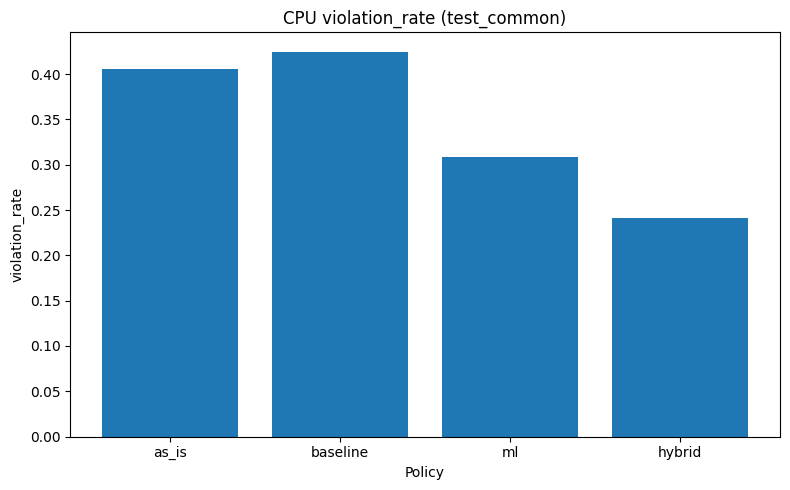

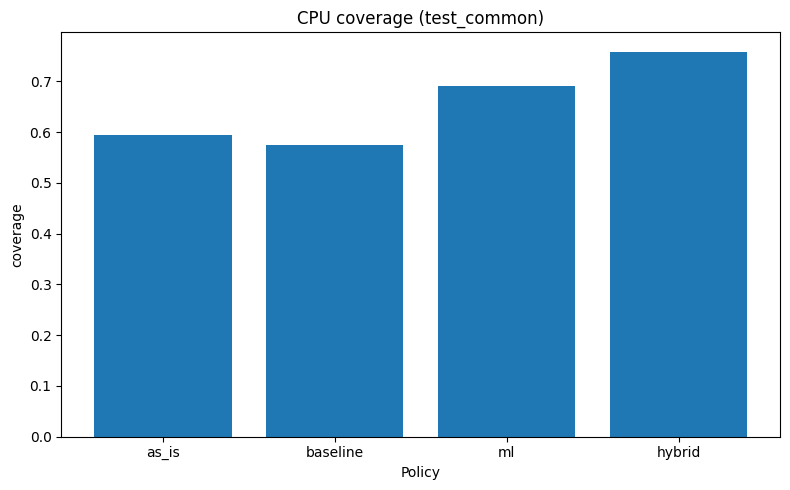

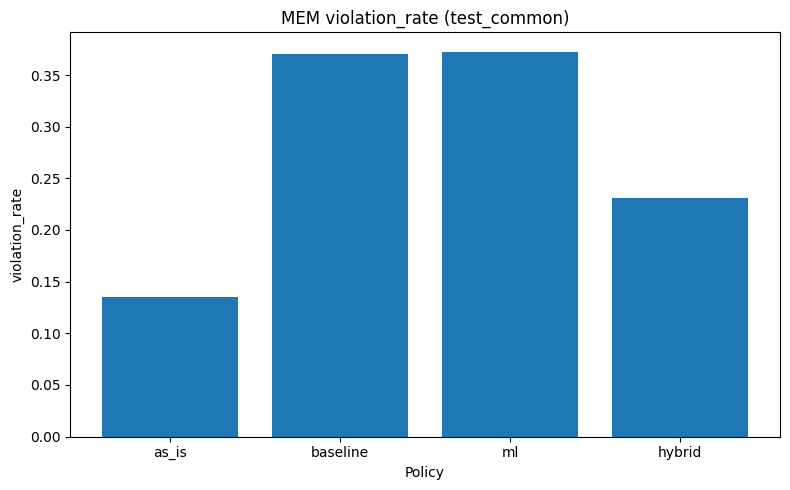

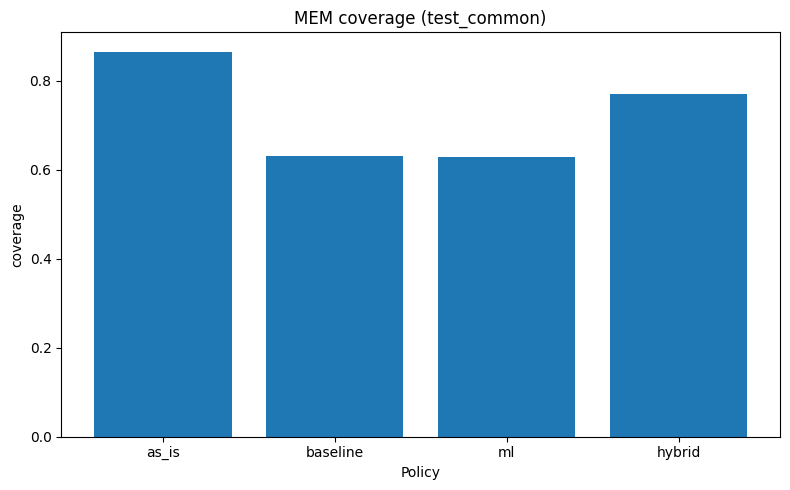

In [227]:
import matplotlib.pyplot as plt

def plot_metric(df, split_name, resource_name, metric_name):
    tmp = df[
        (df["split"] == split_name) &
        (df["resource"] == resource_name)
    ].copy()

    plt.figure(figsize=(8,5))
    plt.bar(tmp["policy"], tmp[metric_name])
    plt.title(f"{resource_name.upper()} {metric_name} ({split_name})")
    plt.xlabel("Policy")
    plt.ylabel(metric_name)
    plt.tight_layout()
    filename = f"{resource_name}_{metric_name}_{split_name}.png"
    plt.savefig(FIG_ML_DIR / filename, dpi=300, bbox_inches="tight")
    plt.show()
    plt.close()


plot_metric(common_test_results, "test_common", "cpu", "violation_rate")
plot_metric(common_test_results, "test_common", "cpu", "coverage")
plot_metric(common_test_results, "test_common", "mem", "violation_rate")
plot_metric(common_test_results, "test_common", "mem", "coverage")

### Final conclusions:
- Hybrid policy improves safety over ML-only.
- CPU benefits strongly from hybrid recommendations.
- Memory remains more conservative and may prefer baseline safeguards.
- ML-only is efficient but often too aggressive.